In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter, AutoLocator
from matplotlib.axes import Axes
import seaborn as sns
from seaborn import (axes_style, plotting_context)
import sklearn.metrics as skm
import colorcet as cc
import sklearn as sk
import sklearn.decomposition as decomp
import sklearn.pipeline as pipe
import sklearn.neighbors as nbr
import sklearn.base as skbase
import sklearn.model_selection as skms
import sklearn.preprocessing as skpr
import pickle
import os
import joblib
import itertools
import statsmodels.api as sma
import statsmodels.formula.api as sf
from statsmodels.discrete.truncated_model import (
    HurdleCountModel,
    TruncatedLFNegativeBinomialP
)
import glob
import anndata as ann
from typing import Literal, Sequence
import scipy as sp
import pymc
import arviz as az
from pytensor.tensor import TensorVariable
import pytensor.tensor as pt
import cvxpy as cx



In [2]:
merged_data = sc.read_h5ad("data/merged_w_others_filt.h5ad")
merged_data

AnnData object with n_obs × n_vars = 111290 × 21318
    obs: 'barcodes', 'sum', 'detected', 'subsets_mito_sum', 'subsets_mito_detected', 'subsets_mito_percent', 'total', 'prob_compromised', 'miQC_pass', 'scpca_filter', 'library_id', 'sample_id', 'scpca_project_id', 'submitter_id', 'participant_id', 'submitter', 'age', 'age_timing', 'sex', 'diagnosis', 'tissue_location', 'disease_timing', 'organism', 'is_xenograft', 'is_cell_line', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'organism_ontology_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'is_primary_data', 'sample', 'leiden', 'sum_log', 'tumor', 'idents'
    var: 'gene_ids', 'gene_symbol', 'mean', 'pct_cells_detected', 'feature_is_filtered', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'dendrogram_leiden', 'diagnosis_colors', 'disease_timing_colors', 'hvg', 'idents_colors

In [3]:
merged_data.layers["norm"] = merged_data.X.copy()
sc.pp.normalize_total(
    merged_data,
    layer= "norm",
    exclude_highly_expressed= True,
    key_added= "norm_factor",
)

sc.pp.downsample_counts(
    merged_data,
    counts_per_cell= np.round(merged_data.obs["sum"] / merged_data.obs["norm_factor"])
)

In [28]:
merged_data.var.sort_values("mean").sample(10)

,gene_ids,gene_symbol,mean,pct_cells_detected,feature_is_filtered,highly_variable,highly_variable_rank,means,variances,variances_norm
ENSG00000074657,ENSG00000074657,ZNF532,0.234793,20.023041,False,False,NaN,0.468317,1.259736,0.737137
ENSG00000288698,ENSG00000288698,ENSG00000288698,0.011406,0.967742,False,False,NaN,0.101303,0.236429,1.290853
ENSG00000237663,ENSG00000237663,DNAJC19P7,0.001152,0.115207,False,False,NaN,0.001321,0.001355,0.969121
ENSG00000234741,ENSG00000234741,GAS5,0.130415,11.877880,False,True,1246.0,1.664965,40.913782,1.959488
ENSG00000166411,ENSG00000166411,IDH3A,0.020737,2.050691,False,False,NaN,0.053302,0.064856,0.795414
ENSG00000112893,ENSG00000112893,MAN2A1,0.174078,14.573733,False,False,NaN,0.502264,1.528668,0.792315
ENSG00000198951,ENSG00000198951,NAGA,0.005760,0.576037,False,False,NaN,0.015868,0.017899,0.865607
ENSG00000100201,ENSG00000100201,DDX17,0.586982,42.131336,False,False,NaN,1.077231,3.354341,0.406149
ENSG00000138668,ENSG00000138668,HNRNPD,0.208180,17.811060,False,False,NaN,0.423237,0.978648,0.680366
ENSG00000282393,ENSG00000282393,ENSG00000282393,0.003802,0.380184,False,False,NaN,0.010711,0.011423,0.852018


In [ ]:
ZEB2 GAS5

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

Sampling: [rna]


Output()

<Axes: xlabel='rna'>

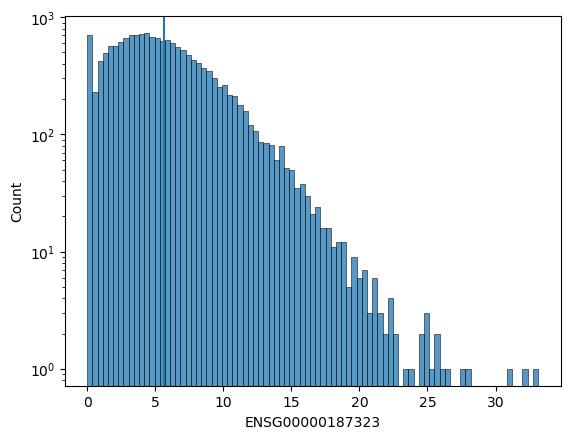

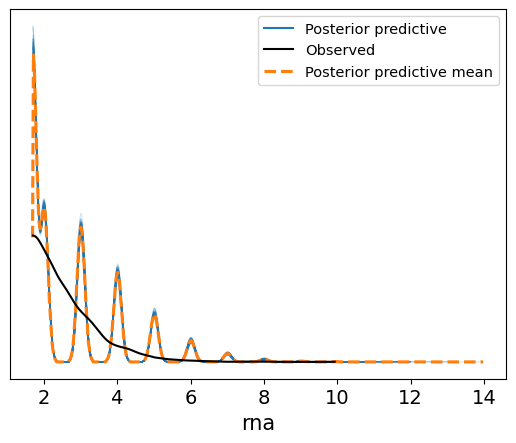

In [11]:
symbol = "DCC"
gene = merged_data.var.query("gene_symbol == @symbol").index[0]
data = merged_data[
    merged_data.obs["idents"] == "Hypoxic Ewing",
    gene
].to_df("norm").iloc[:, 0]
ax = sns.histplot(
    data= data,
)
ax.axvline(x= data.mean())
ax.set_yscale("log")

counts = data.value_counts().reset_index()
counts.columns = ["rna", "counts"]
counts["counts"] = np.log(counts["counts"])

# zero_point = -res.params["Intercept"] / res.params["rna"] * binner.bin_edges_[0][1]
# shift_data = transformed_data - zero_point
# shift_data = shift_data[shift_data >= 0]

scale = merged_data.var.query("gene_symbol == @symbol")["variances_norm"].values[0]
n = data.shape[0]
clip_data = data.copy() 
censor_loc = data.mean()
clip_data[data < censor_loc] = 0
shift = 0.3
clip_data[clip_data != 0] *= shift
clip_data = clip_data[clip_data != 0]
g_alpha = clip_data.sum() 
g_beta = (data >= censor_loc).sum() 
obs_beta = sp.stats.beta.rvs(g_beta, n - g_beta, size= 500)

with pymc.Model() as model:
    lam = pymc.Gamma("lam", alpha= g_alpha + 1, beta= g_beta + 1)
    expectation = pymc.Censored("rna", pymc.NegativeBinomial.dist(mu= lam, alpha= g_alpha), lower= shift * censor_loc, observed= clip_data) 
    # obs_cdf_p = pymc.math.exp(pymc.logcdf(pymc.NegativeBinomial.dist(mu= lam, alpha= g_alpha), censor_loc))
    # proportion_obs = pymc.Beta("pred prop", alpha= obs_cdf_p * n, beta= (1 - obs_cdf_p) * n, observed= obs_beta)
    idata = pymc.sample(nuts_sampler= "numpyro", tune= 3000, draws= 1000)
    thinned_idat = idata.sel(draw= slice(None, None, 50))
    pymc.sample_posterior_predictive(thinned_idat, extend_inferencedata= True)

az.plot_ppc(thinned_idat)

<Axes: xlabel='ENSG00000187323', ylabel='Count'>

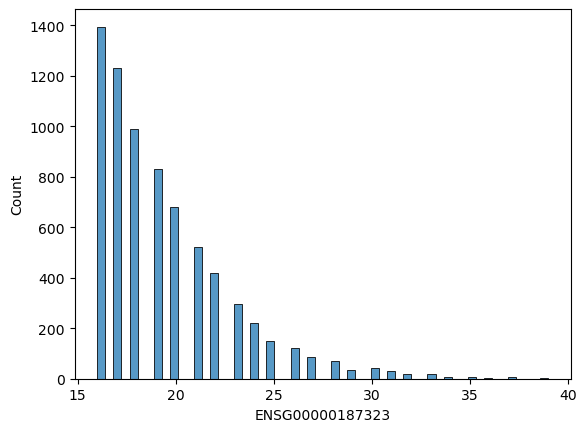

In [99]:
sns.histplot(
    clip_data
)


In [110]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lam,16.371,0.034,16.313,16.438,0.001,0.001,1560.0,2098.0,1.0


In [112]:
mu= idata.posterior["lam"].mean()
est_data = sp.stats.nbinom.rvs(mu, scale= 1, size= n) 
hist_data = pd.Series(clip_data).rename("obs").to_frame().copy()
hist_data["est"] = est_data
hist_data["est_clip"] = est_data
hist_data.loc[hist_data["est_clip"] < mean, "est_clip"] = 0
hist_data = hist_data.melt()
ax = sns.kdeplot(
    hist_data,
    x= "value",
    hue= "variable",
)
ax.set_xlim(right= 2)

TypeError: _parse_args_rvs() got an unexpected keyword argument 'scale'

In [17]:
hist_data

,variable,value
0,obs,0.000000
1,obs,0.000000
2,obs,0.000000
3,obs,1.055696
4,obs,0.000000
...,...,...
48112,est_clip,1.225608
48113,est_clip,0.920698
48114,est_clip,0.000000
48115,est_clip,1.242997


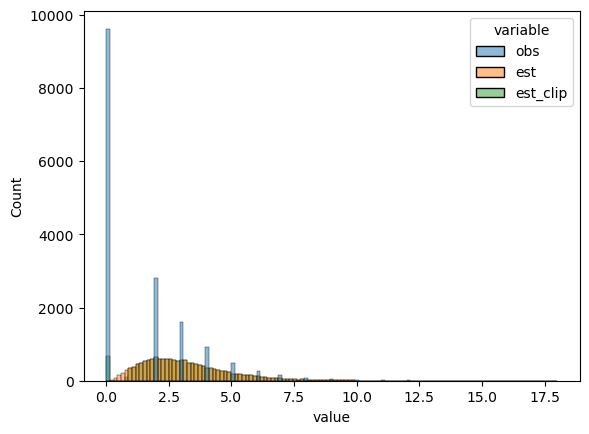

In [21]:
ax = sns.histplot(
    hist_data,
    x= "value",
    hue= "variable",
)
# ax.set_xlim(right= 2)
# ax.set_ylim(top= 250)

In [ ]:
y = np.histogram(data, bins= 50)[0]
nobs = y.shape[0]
x = np.column_stack((np.ones(nobs), np.linspace(0, 1, nobs)))


In [212]:
m = TruncatedLFNegativeBinomialP(
    y,
    x
)

In [213]:
res = m.fit()
res.summary()

/home/gdtheisenlab/jws009/.conda/envs/ewing_atlas/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/home/gdtheisenlab/jws009/.conda/envs/ewing_atlas/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
/home/gdtheisenlab/jws009/.conda/envs/ewing_atlas/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
/home/gdtheisenlab/jws009/.conda/envs/ewing_atlas/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:4329: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/home/gdtheisenlab/jws009/.conda/envs/ewing_atlas/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:3974: RuntimeWarning: divide by zero encountered in log
  

         Current function value: nan
         Iterations: 0
         Function evaluations: 1
         Gradient evaluations: 1


<class 'statsmodels.iolib.summary.Summary'>
"""
                    TruncatedLFNegativeBinomialP Regression Results                     
========================================================================================
Dep. Variable:                                y   No. Observations:                   40
Model:             TruncatedLFNegativeBinomialP   Df Residuals:                       37
Method:                                     MLE   Df Model:                            1
Date:                          Mon, 18 May 2026   Pseudo R-squ.:                     nan
Time:                                  13:44:30   Log-Likelihood:                    nan
converged:                                False   LL-Null:                       -227.96
Covariance Type:                      nonrobust   LLR p-value:                       nan
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -68.8467        nan        nan        nan         nan         nan
x1           805.6516        nan        nan        nan         nan         nan
alpha      -2806.2002        nan        nan        nan         nan         nan
==============================================================================
"""

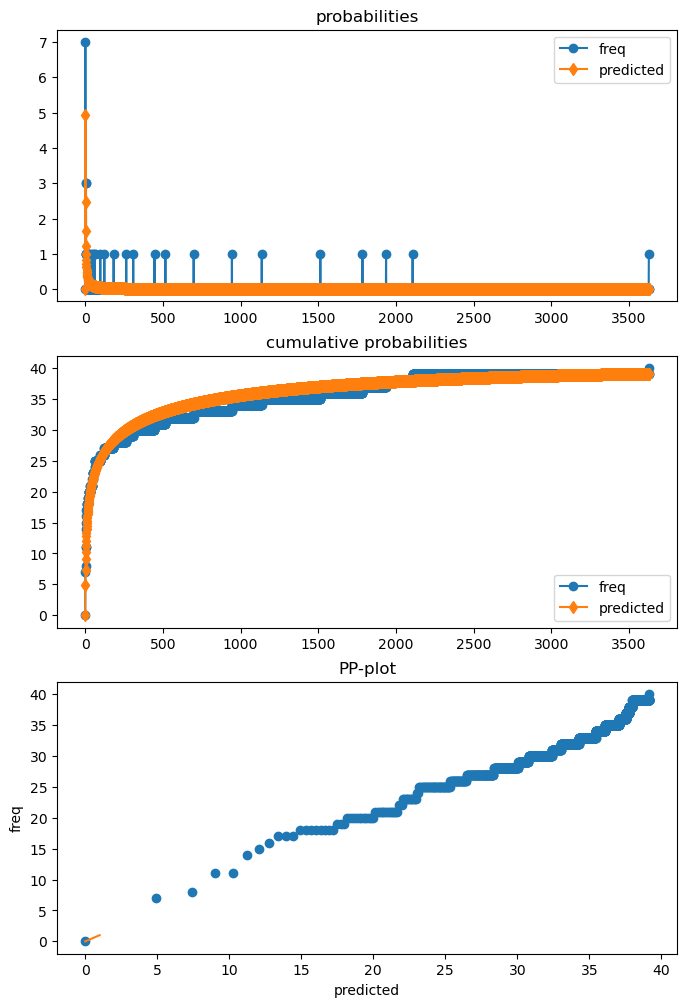

In [209]:
_ = res.get_diagnostic().plot_probs()

<Axes: >

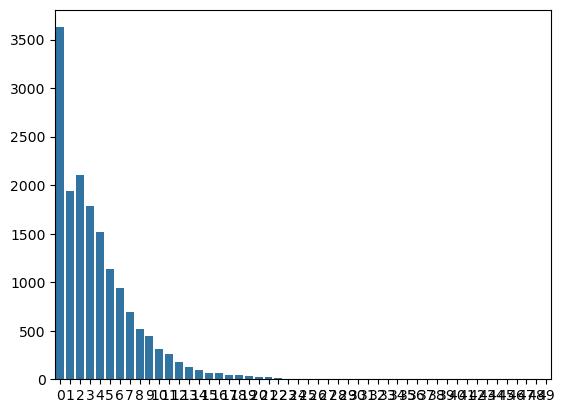

In [210]:
sns.barplot(
    y
)

In [66]:
lam = cx.Variable()
shift = cx.Parameter(value= 1, nonneg= True)
constraints = [
    lam >= 0.1,
    lam <= 100,
    shift >= 0,
    shift <= 10,
]
x = data.values.copy()
x = x[x != 0]
psi = sp.special.digamma(x + 1)
log_gamma = sp.special.gammaln(x + 1)
censor_loc = data.mean()
k = np.arange(censor_loc, data.max())
log_gamma_k = sp.special.gammaln(k + 1)
tests = 100
res = np.zeros(tests)
lams = np.zeros(tests)
objective = cx.Maximize(cx.sum((x + shift) * cx.log(lam) - lam - cx.loggamma((x + shift) + 1))) # + cx.sum(cx.log(cx.cumsum(1 - cx.exp(k * cx.log(lam) - cx.loggamma(k) - lam)))))
prob = cx.Problem(objective, constraints)
res = prob.solve()

(0.0, 2.5)

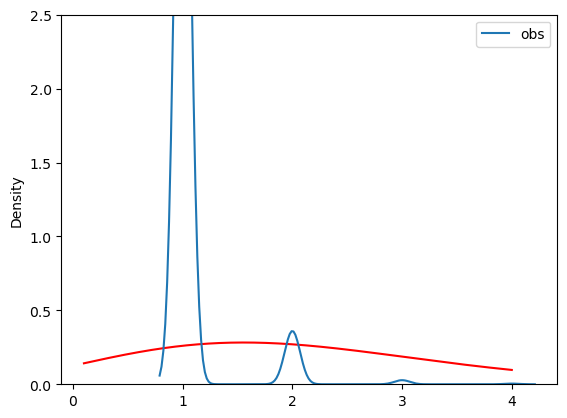

In [67]:
l = lam.value
shift = 0.5
# m = multiplyer[res == res.max()][0]
hist_data = pd.Series(x).rename("obs").to_frame().copy()
x = np.linspace(0.1, data.max(), 1000)
est_data = np.exp((x) * np.log(l) - l - sp.special.gammaln((x + 1)))
ax = sns.lineplot(
    x= x,
    y= est_data,
    color= "red",
)
sns.kdeplot(
    hist_data,
    ax= ax,
)
ax.set_ylim(top= 2.5)

In [ ]:
def log_like(lam, x):
    return cx.log(cx.log(lam) - sp.special.digamma(x + 1)) - cx.loggamma(x + 1) + x * cx.log(lam) - lam

